In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [36]:
df = pd.read_csv("Filtered dataset/Training_data.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nFog label:\n{df['fog_label'].value_counts()}")

Dataset shape: (247101, 18)

Fog label:
fog_label
0    245982
1      1119
Name: count, dtype: int64


In [37]:
total_nan_count = df.isna().sum().sum()
print(f"Total number of NaN values in the entire DataFrame: {total_nan_count}")
print("\nNaN values per column:")
print(df.isna().sum())

Total number of NaN values in the entire DataFrame: 313370

NaN values per column:
timestamp_utc             0
rh_sensor             20052
temp_sensor           20052
pm1                   20405
pm25                  20405
pm10                  20405
Temperature_C         14434
Dew_Point_C           14434
Humidity_%            14434
Speed_kmh              6692
Pressure_hPa           6692
Precip_Rate_mm         6692
Precip_Accum_mm        6692
Wind                  10269
tmpc_ASOS             44240
dewpoint_ASOS         44458
visibility_km_mean    43014
fog_label                 0
dtype: int64


In [38]:
feature_cols_all = [
    "rh_sensor", "temp_sensor", "pm1", "pm25", "pm10",
    "Temperature_C", "Dew_Point_C", "Humidity_%", 
    "Speed_kmh", "Pressure_hPa", "Precip_Rate_mm", "Precip_Accum_mm"
]
X = df[feature_cols_all].dropna(how='any')
y = df.loc[X.index, "fog_label"]
print(f"\nData after removing NaN: {X.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")


Data after removing NaN: (213909, 12)
Class distribution: {0: 212821, 1: 1088}


In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [40]:
rf_all = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

rf_all.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_jobs=-1, random_state=42)

In [41]:
feature_importance = pd.DataFrame({
    'feature': feature_cols_all,
    'importance': rf_all.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance.to_string(index=False))


Feature Importance:
        feature  importance
     Humidity_%    0.366996
      rh_sensor    0.253367
           pm10    0.149696
    temp_sensor    0.045231
Precip_Accum_mm    0.036597
  Temperature_C    0.034969
      Speed_kmh    0.031531
    Dew_Point_C    0.029682
   Pressure_hPa    0.016467
            pm1    0.014779
           pm25    0.012039
 Precip_Rate_mm    0.008647


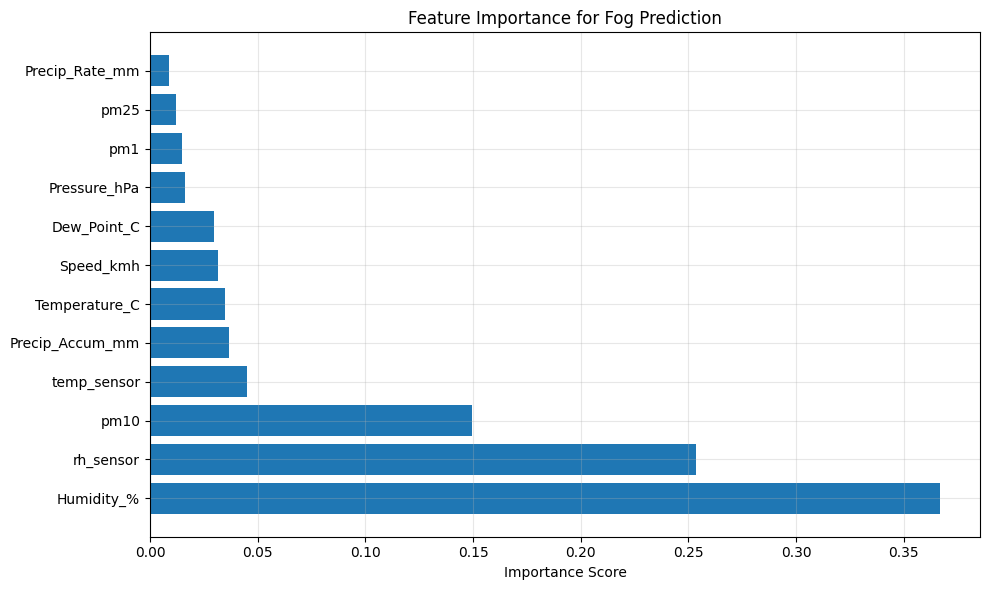

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['feature'], feature_importance['importance'])
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance for Fog Prediction')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
y_pred = rf_all.predict(X_test)

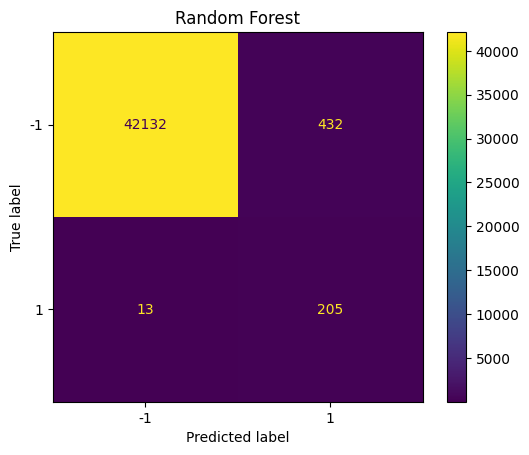

In [44]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 1])
disp.plot()
plt.title("Random Forest")
plt.show()

In [45]:
print(classification_report(y_test, y_pred_all, digits=3))

              precision    recall  f1-score   support

           0      1.000     0.990     0.995     42564
           1      0.322     0.940     0.480       218

    accuracy                          0.990     42782
   macro avg      0.661     0.965     0.737     42782
weighted avg      0.996     0.990     0.992     42782

